In [15]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [9]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr:float
    bpd:float
    boundary_percentage:float
    summary: str

In [31]:
def strike_rate(state:BatsmanState):
    sr = (state['runs']/state['balls'])*100
    state['sr']=sr
    return {'sr':sr}

In [ ]:
def bpd(state:BatsmanState):
    bpd = state['balls']/(state['fours']+ state['sixes'])

    state['bpd']=bpd

    return {'bpd':bpd}

In [25]:
def boundary_percentage(state:BatsmanState):

    boundary_percent=(((state['fours']*4) + (state['sixes']*6))/state['runs'])*100

    state['boundary_percentage']=boundary_percent

    return {'boundary_percentage':boundary_percent}

In [26]:
def summary(state:BatsmanState):
    summary = f"""
    Strike Rate - {state['sr']}\n
    Balls per Boundary - {state['bpd']}\n
    Boundary Percentage - {state['boundary_percentage']}
    """
    state['summary']=summary
    return {'summary':summary}


In [27]:
graph= StateGraph(BatsmanState)

graph.add_node('calculate_sr', strike_rate)
graph.add_node('calculate_bpd', bpd)
graph.add_node('calculate_boundary_percentage', boundary_percentage)
graph.add_node('summary',summary)

# Define edges
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpd')
graph.add_edge(START, 'calculate_boundary_percentage')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpd', 'summary')
graph.add_edge('calculate_boundary_percentage', 'summary')

graph.add_edge('summary', END)

workflow =graph.compile()

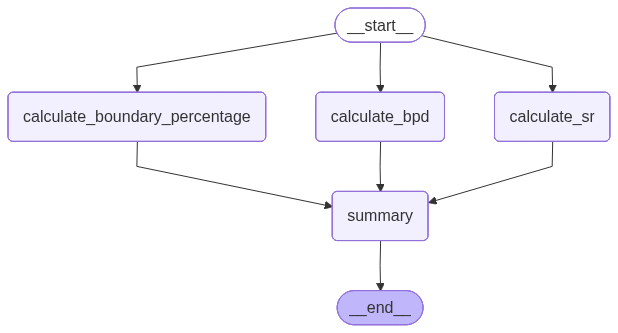

In [28]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [29]:
initial_state = {
    'runs': 120,
    'balls': 100,
    'fours': 10,
    'sixes': 5
}


In [30]:
workflow.invoke(initial_state)

{'runs': 120,
 'balls': 100,
 'fours': 10,
 'sixes': 5,
 'sr': 0.012,
 'bpd': 6.666666666666667,
 'boundary_percentage': 58.333333333333336,
 'summary': '\n    Strike Rate - 0.012\n\n    Balls per Boundary - 6.666666666666667\n\n    Boundary Percentage - 58.333333333333336\n    '}

In [ ]:
# Parallel workflow require exact variable to be updated rather than return state.
# It's called partial state update..